# Career Compass — Recommendation Models

This notebook builds and demonstrates the recommendation-model deliverables on top
of the Person 1 package in `src/`:

1. Prepare the recommendation feature matrix
2. Handle remaining missing values in modeling features
3. Scale/normalize the modeling variables
4. Build the interpretable weighted compatibility model
5. Separate compatibility components (Interests, Skills, Education, Job Zone, Labor-market)
6. Cosine-similarity recommender
7. K-nearest-neighbors recommender
8. Test different feature weights and values of K
9. Recommendation explanations
10. Record top recommendations from every model, for every evaluation profile

The reusable logic lives in `src/feature_matrix.py`, `src/scaling.py`,
`src/compatibility.py`, `src/vector_builder.py`, `src/cosine_model.py`,
`src/knn_model.py`, `src/sensitivity.py`, `src/explain.py`, and `src/evaluate.py` —
this notebook imports and exercises those modules rather than re-implementing them,
so `run_all.py` and this notebook stay in sync.

Evaluation profiles are still the six temporary `TEST_PROFILES` from
`src/test_profiles.py`, per the README's Person 3 handoff note.

## Steps 1-2: Feature Matrix and Missing Values

`build_feature_matrices` slices the master dataset into five named component
matrices (interest, skill, education, job_zone, labor_market), drops occupations
with no OEWS wage/employment estimate (not recommendable — imputing a fake wage
would misrepresent them), and median-imputes the smaller remaining gaps in the
rating-scale columns.

In [1]:
import pandas as pd

from src.config import DATA_PATH
from src.data_prep import load_master_data, create_person1_modeling_data
from src.feature_matrix import build_feature_matrices

master = load_master_data(DATA_PATH)
modeling = create_person1_modeling_data(master)

matrices = build_feature_matrices(modeling)

print("\nComponent matrix shapes:")
for name in ["interest", "skill", "education", "job_zone", "labor_market"]:
    block = getattr(matrices, name)
    print(f"  {name:14s} {block.shape}")

Dropped 60 / 1016 occupations missing labor-market data (no OEWS wage/employment estimate). Not recommendable.
Median-imputing remaining gaps in 38 columns for the 956 eligible occupations:
interest_realistic                                          69
interest_investigative                                      69
interest_artistic                                           69
interest_social                                             69
interest_enterprising                                       69
interest_conventional                                       69
essential_skill_active_learning_im                          94
essential_skill_active_listening_im                         94
essential_skill_critical_thinking_im                        94
essential_skill_mathematics_im                              94
essential_skill_reading_comprehension_im                    94
essential_skill_science_im                                  94
essential_skill_speaking_im                           

## Step 3: Scaling

Each block is scaled onto `[0, 1]` using documented scale bounds (O*NET's Scales
Reference / the questionnaire's own option ranges), not empirically-fit bounds —
see `src/scaling.py` for why: RIASEC scores are on O*NET's native 1-7 scale while
the questionnaire slider only collects 1-5, and `education_expected_category` is a
continuous ~1-12 weighted average while the questionnaire offers a 5-level
preference. Both mismatches are reconciled explicitly rather than silently
comparing incompatible numbers.

In [2]:
from src.scaling import scale_matrices

scaled = scale_matrices(matrices)

print("Interest block (scaled 0-1), first 3 occupations:")
display(scaled.interest.head(3))

print("\nEducation / Job Zone (scaled 0-1), first 5 occupations:")
display(pd.concat([scaled.education.rename("education_scaled"), scaled.job_zone.rename("job_zone_scaled")], axis=1).head())

Interest block (scaled 0-1), first 3 occupations:


,interest_realistic,interest_investigative,interest_artistic,interest_social,interest_enterprising,interest_conventional
onet_soc_code,,,,,,
11-1011.00,0.043333,0.341667,0.193333,0.423333,0.993333,0.661667
11-1011.03,0.173333,0.630000,0.246667,0.425000,0.946667,0.581667
11-1021.00,0.200000,0.228333,0.048333,0.396667,1.000000,0.723333



Education / Job Zone (scaled 0-1), first 5 occupations:


,education_scaled,job_zone_scaled
onet_soc_code,,
11-1011.00,1.0,1.00
11-1011.03,1.0,1.00
11-1021.00,0.5,0.75
11-2011.00,0.5,0.75
11-2021.00,1.0,0.75


## Steps 4-5: Interpretable Weighted Compatibility Model

`compute_weighted_compatibility` combines the five component scores (interest,
skill, education, job_zone, labor_market — each individually bounded to `[0, 1]`)
into one overall score, using `DEFAULT_WEIGHTS`. Every component score is kept on
the result, not just the total, so the ranking is explainable without recomputation.

In [3]:
from src.compatibility import compute_weighted_compatibility, DEFAULT_WEIGHTS
from src.test_profiles import TEST_PROFILES

demo_profile = TEST_PROFILES[0]  # "Data and Technology"
print(f"Demo profile: {demo_profile.profile_name}")
print(f"Default weights: {DEFAULT_WEIGHTS}\n")

weighted_results = compute_weighted_compatibility(matrices, scaled, demo_profile, top_n=10)
display(weighted_results[[
    "rank", "occupation_title", "overall_score",
    "interest_score", "skill_score", "education_score", "job_zone_score", "labor_market_score",
]])

Demo profile: Data and Technology
Default weights: {'interest': 0.3, 'skill': 0.3, 'education': 0.15, 'job_zone': 0.1, 'labor_market': 0.15}



,rank,occupation_title,overall_score,interest_score,skill_score,education_score,job_zone_score,labor_market_score
0,1,Software Developers,0.815733,0.950827,0.459392,1.0,1.0,0.951115
1,2,Clinical Data Managers,0.797742,0.953271,0.448616,1.0,1.0,0.847837
2,3,Computer Network Architects,0.79647,0.961701,0.435680,1.0,1.0,0.848373
3,4,Business Intelligence Analysts,0.795673,0.967768,0.427224,1.0,1.0,0.847837
4,5,Computer Systems Engineers/Architects,0.795595,0.955547,0.424485,1.0,1.0,0.877233
5,6,Computer Systems Analysts,0.794073,0.966176,0.414389,1.0,1.0,0.866025
6,7,Data Warehousing Specialists,0.793893,0.949378,0.482241,1.0,1.0,0.762720
7,8,Database Architects,0.793235,0.973181,0.456243,1.0,1.0,0.762720
8,9,Web Administrators,0.791569,0.966559,0.400056,1.0,1.0,0.877233
9,10,Geographic Information Systems Technologists a...,0.790304,0.920198,0.442198,1.0,1.0,0.877233


## Step 6: Cosine-Similarity Recommender

Ranks occupations by cosine similarity between the user's combined feature vector
and each occupation's, using the same five components and weights but combined
into one vector (via `vector_builder`, which corrects for the blocks having very
different widths — 30 skill columns vs. 1 job-zone column — so a block's influence
tracks its assigned weight, not its dimensionality).

In [4]:
from src.cosine_model import recommend_cosine

cosine_results = recommend_cosine(matrices, scaled, demo_profile, top_n=10)
display(cosine_results[["rank", "occupation_title", "cosine_similarity", "interest_score", "skill_score"]])

,rank,occupation_title,cosine_similarity,interest_score,skill_score
0,1,Business Intelligence Analysts,0.895054,0.967768,0.427224
1,2,Software Developers,0.895044,0.950827,0.459392
2,3,Data Warehousing Specialists,0.889799,0.949378,0.482241
3,4,Clinical Data Managers,0.889740,0.953271,0.448616
4,5,Financial Quantitative Analysts,0.889498,0.983690,0.460885
5,6,Database Architects,0.887591,0.973181,0.456243
6,7,Computer Programmers,0.884062,0.945018,0.498981
7,8,Information Security Analysts,0.883373,0.953738,0.382190
8,9,Intelligence Analysts,0.882024,0.993953,0.353529
9,10,Operations Research Analysts,0.881074,0.989890,0.454954


## Step 7: K-Nearest-Neighbors Recommender

Uses `NearestNeighbors` for retrieval (find the k closest occupations to the
user's query point) with **Euclidean** distance rather than cosine — that's the
deliberate difference from the model above: Euclidean distance is sensitive to
absolute position in the scaled feature space, not just direction, so it can (and
does, below) produce a different ranking than cosine similarity on the identical
input vectors.

In [5]:
from src.knn_model import recommend_knn

knn_results = recommend_knn(matrices, scaled, demo_profile, k=10)
display(knn_results[["rank", "occupation_title", "euclidean_distance", "knn_similarity"]])

overlap = set(weighted_results["onet_soc_code"].head(5)) & set(cosine_results["onet_soc_code"].head(5)) & set(knn_results["onet_soc_code"].head(5))
print(f"\nOccupations in all three models' top-5 for '{demo_profile.profile_name}': {len(overlap)} / 5")

,rank,occupation_title,euclidean_distance,knn_similarity
0,1,Business Intelligence Analysts,0.270698,0.786969
1,2,Software Developers,0.274820,0.784424
2,3,Data Warehousing Specialists,0.275514,0.783998
3,4,Database Architects,0.279735,0.781412
4,5,Clinical Data Managers,0.280473,0.780961
5,6,Computer Programmers,0.282097,0.779972
6,7,Intelligence Analysts,0.283918,0.778866
7,8,Information Security Analysts,0.285809,0.777721
8,9,Digital Forensics Analysts,0.288185,0.776286
9,10,Blockchain Engineers,0.289677,0.775388



Occupations in all three models' top-5 for 'Data and Technology': 3 / 5


## Step 8: Testing Feature Weights and Values of K

There is no labeled ground truth for this recommender (the "target" is a
similarity score, not a learned label — see `EDA_Report.md`'s Q&A), so this is a
**sensitivity/stability check**, not accuracy tuning: do rankings shift sensibly as
weights change, and are KNN neighbor sets stable as K changes rather than
reordering wildly?

In [6]:
from src.sensitivity import test_weight_configurations, WEIGHT_CONFIGURATIONS

weight_sensitivity = test_weight_configurations(matrices, scaled, [demo_profile], top_n=5)

for config_name in WEIGHT_CONFIGURATIONS:
    titles = weight_sensitivity[weight_sensitivity["weight_config"] == config_name].sort_values("rank")["occupation_title"].tolist()
    print(f"{config_name:30s} {titles}")

balanced_default               ['Software Developers', 'Clinical Data Managers', 'Computer Network Architects', 'Business Intelligence Analysts', 'Computer Systems Engineers/Architects']
interest_heavy                 ['Software Developers', 'Database Architects', 'Business Intelligence Analysts', 'Computer Network Architects', 'Computer Systems Analysts']
skill_heavy                    ['Software Developers', 'Computer Programmers', 'Data Warehousing Specialists', 'Clinical Data Managers', 'Geographic Information Systems Technologists and Technicians']
labor_market_heavy             ['Software Developers', 'Computer and Information Systems Managers', 'Brownfield Redevelopment Specialists and Site Managers', 'Financial Managers', 'Wind Energy Development Managers']
education_and_job_zone_heavy   ['Software Developers', 'Clinical Data Managers', 'Computer Systems Engineers/Architects', 'Computer Network Architects', 'Business Intelligence Analysts']


,profile_name,k,top_5_titles,jaccard_overlap_vs_previous_k
0,Data and Technology,5,"Business Intelligence Analysts, Software Devel...",NaN
1,Data and Technology,10,"Business Intelligence Analysts, Software Devel...",1.0
2,Data and Technology,20,"Business Intelligence Analysts, Software Devel...",1.0
3,Data and Technology,50,"Business Intelligence Analysts, Software Devel...",1.0
4,Healthcare,5,"Hospitalists, Physical Therapists, Nurse Pract...",NaN
5,Healthcare,10,"Hospitalists, Physical Therapists, Nurse Pract...",1.0
6,Healthcare,20,"Hospitalists, Physical Therapists, Nurse Pract...",1.0
7,Healthcare,50,"Hospitalists, Physical Therapists, Nurse Pract...",1.0
8,Business,5,"Wind Energy Development Managers, Project Mana...",NaN
9,Business,10,"Wind Energy Development Managers, Project Mana...",1.0


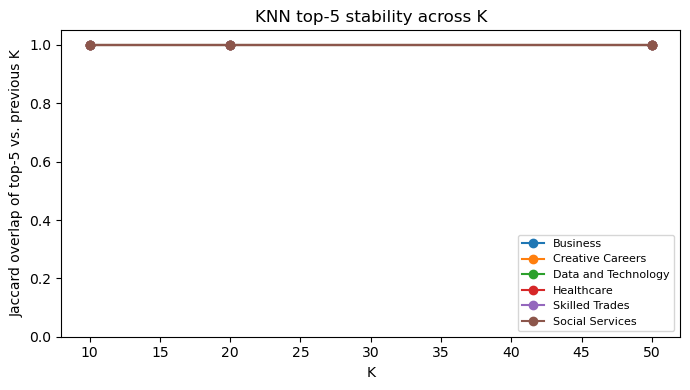

In [7]:
import matplotlib.pyplot as plt
from src.sensitivity import test_k_values, K_VALUES

k_sensitivity = test_k_values(matrices, scaled, TEST_PROFILES, k_values=K_VALUES)
display(k_sensitivity)

fig, ax = plt.subplots(figsize=(7, 4))
for profile_name, group in k_sensitivity.dropna(subset=["jaccard_overlap_vs_previous_k"]).groupby("profile_name"):
    ax.plot(group["k"], group["jaccard_overlap_vs_previous_k"], marker="o", label=profile_name)
ax.set_xlabel("K")
ax.set_ylabel("Jaccard overlap of top-5 vs. previous K")
ax.set_ylim(0, 1.05)
ax.set_title("KNN top-5 stability across K")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## Step 9: Recommendation Explanations

`explain_recommendations` is model-agnostic — it works on the output of any of the
three recommenders above, since they all expose the same five component scores.
Components are ranked by their **weighted contribution** (`weight * score`), not
raw score: education/job-zone scores saturate at 1.0 for every occupation at or
below a user's stated ceiling (by design — being over-qualified isn't penalized),
which would otherwise make them look like the "strongest" match for nearly every
recommendation even when skill/interest actually drove the ranking.

In [8]:
from src.explain import explain_recommendations

explained_weighted = explain_recommendations(weighted_results, matrices, scaled, demo_profile)
explained_cosine = explain_recommendations(cosine_results, matrices, scaled, demo_profile)
explained_knn = explain_recommendations(knn_results, matrices, scaled, demo_profile)

for name, df in [("Weighted", explained_weighted), ("Cosine", explained_cosine), ("KNN", explained_knn)]:
    print(f"--- {name} model, top 3 for '{demo_profile.profile_name}' ---")
    for _, row in df.sort_values("rank").head(3).iterrows():
        print(f"  {row['rank']}. {row['occupation_title']} -- {row['why']}")
    print()

--- Weighted model, top 3 for 'Data and Technology' ---
  1. Software Developers -- Strongest fit: Interests (Investigative interest, 0.95); Education fit (1.00).
  2. Clinical Data Managers -- Strongest fit: Interests (Investigative interest, 0.95); Education fit (1.00).
  3. Computer Network Architects -- Strongest fit: Interests (Investigative interest, 0.96); Education fit (1.00).

--- Cosine model, top 3 for 'Data and Technology' ---
  1. Business Intelligence Analysts -- Strongest fit: Interests (Investigative interest, 0.97); Education fit (1.00).
  2. Software Developers -- Strongest fit: Interests (Investigative interest, 0.95); Education fit (1.00).
  3. Data Warehousing Specialists -- Strongest fit: Interests (Conventional interest, 0.95); Education fit (1.00).

--- KNN model, top 3 for 'Data and Technology' ---
  1. Business Intelligence Analysts -- Strongest fit: Interests (Investigative interest, 0.97); Education fit (1.00).
  2. Software Developers -- Strongest fit: Inte

## Step 10: Record Top Recommendations From Every Model, For Every Profile

`run_all_models_for_profiles` runs the weighted, cosine, and KNN recommenders
across all six `TEST_PROFILES`. This notebook only *computes and displays* the
result — it does not call `save_results`, so viewing/re-running this notebook
never overwrites `outputs/`. `run_all.py` is the single place that writes
`weighted_top10_results.csv`, `cosine_top10_results.csv`, `knn_top10_results.csv`,
and `model_comparison_top5.csv` to disk.

In [9]:
from src.evaluate import run_all_models_for_profiles, RESULT_COLUMNS

all_results = run_all_models_for_profiles(matrices, scaled, TEST_PROFILES, top_n=10)

for name, df in all_results.items():
    print(f"{name:10s} {len(df)} rows computed ({df['profile_name'].nunique()} profiles x top-10)")

# In-memory preview only -- run_all.py is what actually writes outputs/*.csv.
available_columns = [c for c in RESULT_COLUMNS if c in all_results["weighted"].columns]
comparison_preview = pd.concat(
    [df[available_columns][df[available_columns]["rank"] <= 5] for df in all_results.values()],
    ignore_index=True,
).sort_values(["profile_name", "model", "rank"])

display(comparison_preview[comparison_preview["profile_name"] == demo_profile.profile_name])

weighted   60 rows computed (6 profiles x top-10)
cosine     60 rows computed (6 profiles x top-10)
knn        60 rows computed (6 profiles x top-10)


,model,profile_name,rank,onet_soc_code,soc_code,occupation_title,interest_score,skill_score,education_score,job_zone_score,labor_market_score,why
30,cosine,Data and Technology,1,15-2051.01,15-2051,Business Intelligence Analysts,0.967768,0.427224,1.0,1.0,0.847837,Strongest fit: Interests (Investigative intere...
31,cosine,Data and Technology,2,15-1252.00,15-1252,Software Developers,0.950827,0.459392,1.0,1.0,0.951115,Strongest fit: Interests (Investigative intere...
32,cosine,Data and Technology,3,15-1243.01,15-1243,Data Warehousing Specialists,0.949378,0.482241,1.0,1.0,0.762720,Strongest fit: Interests (Conventional interes...
33,cosine,Data and Technology,4,15-2051.02,15-2051,Clinical Data Managers,0.953271,0.448616,1.0,1.0,0.847837,Strongest fit: Interests (Investigative intere...
34,cosine,Data and Technology,5,13-2099.01,13-2099,Financial Quantitative Analysts,0.983690,0.460885,0.0,0.0,0.679494,Strongest fit: Interests (Investigative intere...
60,knn,Data and Technology,1,15-2051.01,15-2051,Business Intelligence Analysts,0.967768,0.427224,1.0,1.0,0.847837,Strongest fit: Interests (Investigative intere...
61,knn,Data and Technology,2,15-1252.00,15-1252,Software Developers,0.950827,0.459392,1.0,1.0,0.951115,Strongest fit: Interests (Investigative intere...
62,knn,Data and Technology,3,15-1243.01,15-1243,Data Warehousing Specialists,0.949378,0.482241,1.0,1.0,0.762720,Strongest fit: Interests (Conventional interes...
63,knn,Data and Technology,4,15-1243.00,15-1243,Database Architects,0.973181,0.456243,1.0,1.0,0.762720,Strongest fit: Interests (Investigative intere...
64,knn,Data and Technology,5,15-2051.02,15-2051,Clinical Data Managers,0.953271,0.448616,1.0,1.0,0.847837,Strongest fit: Interests (Investigative intere...


## Summary

- Feature matrix: 5 named component matrices built from the 1,016-occupation
  master file; 60 occupations dropped for missing OEWS labor-market data, small
  remaining gaps in the other four blocks median-imputed.
- Scaling: fixed documented scale bounds used instead of empirically-fit bounds,
  which surfaced (and fixed) two real scale mismatches between the questionnaire
  and the underlying O*NET data (RIASEC 1-5 vs. 1-7; education 1-5 vs. ~1-12).
- Three recommenders (weighted, cosine, KNN) share the same five compatibility
  components and the same combined feature space, so their outputs are directly
  comparable rather than being three unrelated approaches.
- Weight sensitivity: shifting weight toward labor-market vs. interest/skill
  visibly changes the top-5 in sensible directions (e.g. toward higher-paying
  management roles vs. toward more technically-specific occupations).
- K sensitivity: top-5 neighbor sets were stable (Jaccard overlap = 1.0) across
  K = 5, 10, 20, 50 for the profiles tested here — the recommendation isn't
  fragile to the exact K chosen, at least for these six profiles.
- Explanations are model-agnostic and rank by weighted contribution rather than
  raw score, avoiding the saturated-education/job-zone-score trap.

Next step per the README: replace `TEST_PROFILES` with Person 3's finalized,
documented evaluation profiles once approved, and re-run this notebook / `run_all.py`.